In [13]:
# --- CELL 1: SETUP ---

import os
import operator
from typing import TypedDict, List, Annotated
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [15]:
# --- CELL 2: THE SHARED CLIPBOARD (FIXED STATE) ---
class SentinelState(TypedDict):
    objective: str
    delegated_tasks: List[str]
    manager_reports: Annotated[List[str], operator.add]
    final_product: str

In [16]:
# --- CELL 3: THE CORPORATE HIERARCHY (NODES) ---

def ceo_node(state: SentinelState):
    print("🏢 CEO: Receiving high-level goal...")
    # CEO breaks down the goal into departments
    return {
        "delegated_tasks": ["Market Research Mission", "Financial Audit Mission"],
        "manager_reports": []
    }

def research_manager_node(state: SentinelState):
    print("📂 Research Manager: Executing Market Mission...")
    # Manager handles the complexity of the research
    report = "Research Dept: Market demand is high for AI-integrated tools."
    return {"manager_reports": state["manager_reports"] + [report]}

def finance_manager_node(state: SentinelState):
    print("💰 Finance Manager: Executing Audit Mission...")
    # Manager handles the complexity of the finances
    report = "Finance Dept: Budget is healthy with 20% growth year-over-year."
    return {"manager_reports": state["manager_reports"] + [report]}

def aggregator_ceo_node(state: SentinelState):
    print("🏛️ CEO: Consolidating departmental reports into final product...")
    summary = "\n".join(state["manager_reports"])
    return {"final_product": f"EXECUTIVE SUMMARY:\n{summary}"}

In [17]:
# --- CELL 4: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

builder.add_node("ceo_planning", ceo_node)
builder.add_node("research_dept", research_manager_node)
builder.add_node("finance_dept", finance_manager_node)
builder.add_node("ceo_finalizing", aggregator_ceo_node)

# Flow: Start -> CEO -> Parallel Depts -> CEO Finalizing
builder.add_edge(START, "ceo_planning")

# CEO delegates to both departments at once (Parallelism inside Hierarchy)
builder.add_edge("ceo_planning", "research_dept")
builder.add_edge("ceo_planning", "finance_dept")

# Both depts report back to the CEO for the final assembly
builder.add_edge("research_dept", "ceo_finalizing")
builder.add_edge("finance_dept", "ceo_finalizing")

builder.add_edge("ceo_finalizing", END)

sentinel_hierarchy = builder.compile()

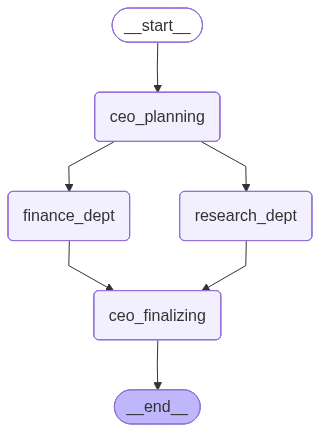

In [18]:
# --- CELL 5: VISUALIZATION ---
try:
    png_bytes = sentinel_hierarchy.get_graph().draw_mermaid_png()
    with open("sentinel_hierarchy.png", "wb") as f:
        f.write(png_bytes)
    display(Image(data=png_bytes))
except Exception as e:
    print(f"Visualization skip: {e}")

In [19]:
# --- CELL 6: RUNNING THE ORG CHART ---
print("\n--- EXECUTING HIERARCHICAL MISSION ---")
result = sentinel_hierarchy.invoke({"objective": "Expand operations to New York."})
print("\n" + result['final_product'])


--- EXECUTING HIERARCHICAL MISSION ---
🏢 CEO: Receiving high-level goal...
💰 Finance Manager: Executing Audit Mission...
📂 Research Manager: Executing Market Mission...
🏛️ CEO: Consolidating departmental reports into final product...

EXECUTIVE SUMMARY:
Finance Dept: Budget is healthy with 20% growth year-over-year.
Research Dept: Market demand is high for AI-integrated tools.
